In [ ]:
%pip list

In [ ]:
%pip install pandas matplotlib seaborn

### 1. Importing the required libraries for EDA

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Loading data into data frame

In [2]:
path_to_df = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not os.path.isfile(path_to_df):
    print("not ok")
else:
    df = pd.read_csv(path_to_df)

In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.head(n=3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### 3. Checking data types

In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 4. Duplicates or NaNs

In [8]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.shape

(0, 21)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### 5. Outliers

In [ ]:
df.info()

In [12]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [13]:
df['tenure'].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

In [14]:
df['MonthlyCharges'].value_counts()

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
19.70     43
          ..
72.00      1
108.35     1
63.10      1
44.20      1
78.70      1
Name: count, Length: 1585, dtype: int64

<Axes: >

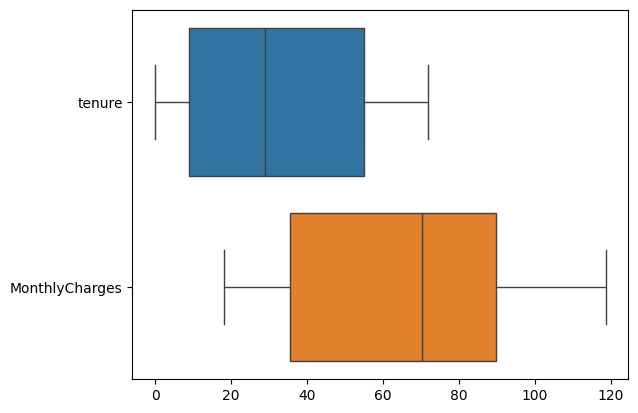

In [15]:
sns.boxplot(data=df[["tenure", "MonthlyCharges"]], orient="h")


In [16]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

54.349999999999994


In [17]:
df.shape

(7043, 21)

In [18]:
df[((df['MonthlyCharges'] < (Q1 - 1.5 * IQR)) |(df['MonthlyCharges'] > (Q3 + 1.5 * IQR)))]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


### 6. Plotting different features against one another

<Axes: xlabel='Churn', ylabel='count'>

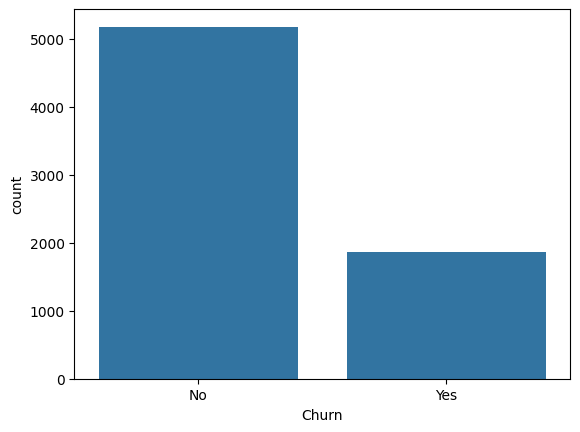

In [19]:
sns.countplot(x='Churn', data=df)

In [20]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

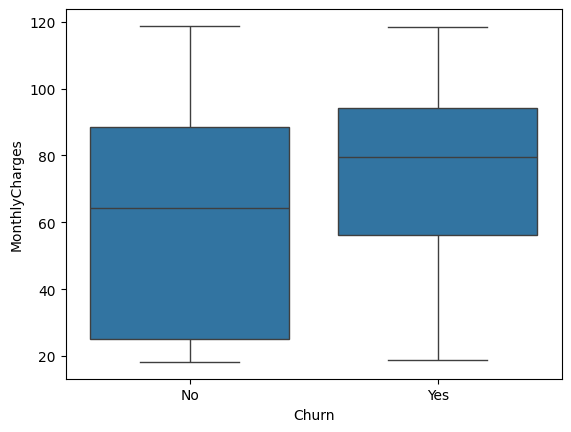

In [21]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

OBS:

-   When MontlyCharges is higher, customers tend to churn. Higher charges => unsatisfied customer => leaves

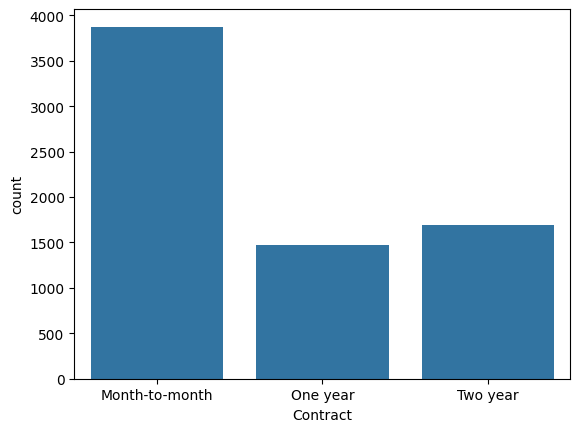

In [22]:
sns.countplot(x="Contract", data=df)
plt.show()

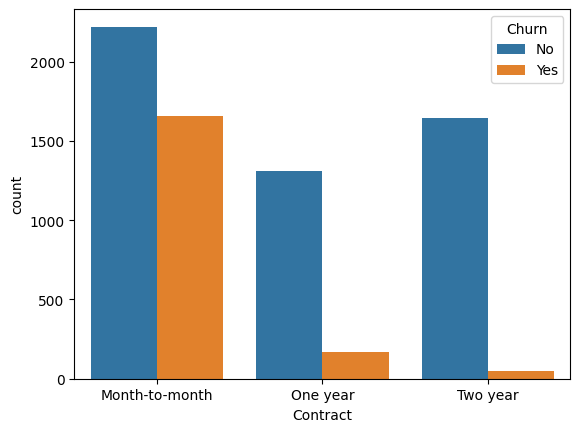

In [23]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

OBS:

-   Customers with Month-to-month contracts are more likely to churn compared to those with One year + contracts

When to contract is one year or more the customers may have discounts so they are more likely to stay + penalties if they want termination

### 7. Feature Engineering

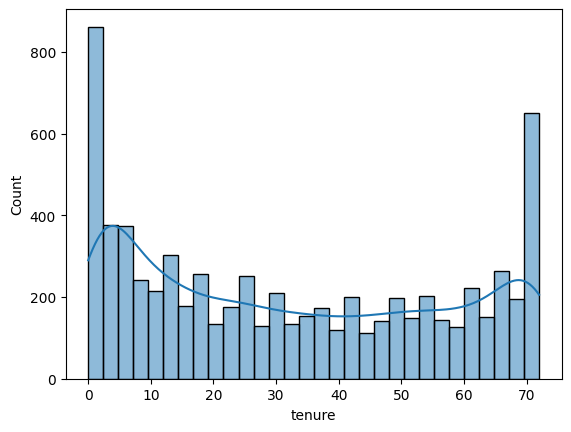

In [24]:
sns.histplot(df['tenure'], bins=30, kde=True)
plt.show()

OBS:

-   tenure -> tenure_groups with values ['new', 'medium', 'old']

In [25]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [26]:
df['tenure_group'] = pd.cut(df['tenure'], 
                            bins=[0, 10, 50, 72],
                            labels=['new', 'medium', 'old'])

In [27]:
df['tenure_group'].value_counts()

tenure_group
medium    2968
old       2105
new       1959
Name: count, dtype: int64

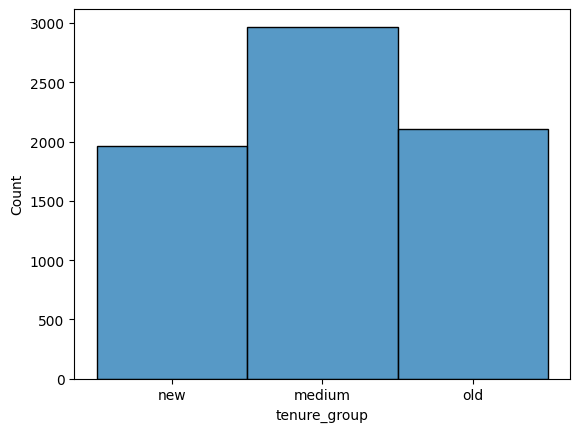

In [28]:
sns.histplot(df['tenure_group'])
plt.show()

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

In [30]:
df['TotalCharges'].head(n=5)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [31]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
tenure_group           3
dtype: int64

In [32]:
numeric_col = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_col = [col for col in df.columns if col not in numeric_col + ["Churn"] + ["customerID"]]

In [33]:
print("Numeric columns:", numeric_col)
print("Categorical columns:", categorical_col)

Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [34]:
df_encoded = pd.get_dummies(df, columns=categorical_col, drop_first=True)
df_encoded.head(n=3)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_medium,tenure_group_old
0,7590-VHVEG,1,29.85,29.85,No,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
1,5575-GNVDE,34,56.95,1889.5,No,True,False,False,False,True,...,False,False,True,False,False,False,False,True,True,False
2,3668-QPYBK,2,53.85,108.15,Yes,True,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False


In [35]:
df_encoded.dtypes[:4]

customerID            str
tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object

In [36]:
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors="coerce")

In [37]:
df_encoded.dtypes[:4]

customerID            str
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

In [38]:
df_encoded['TotalCharges'].isna().sum()

np.int64(11)

In [39]:
df_encoded.dropna(subset=['TotalCharges'], inplace=True)
df_encoded['TotalCharges'].isna().sum()

np.int64(0)

<Axes: xlabel='TotalCharges', ylabel='Count'>

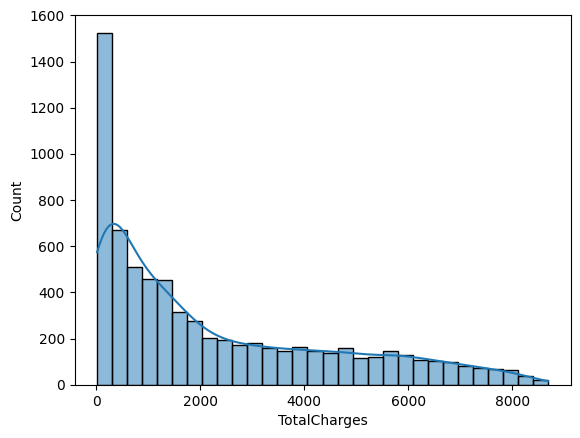

In [40]:
sns.histplot(df_encoded["TotalCharges"], bins=30, kde=True)

### 8. Scaling numeric features

In [ ]:
%pip install scikit-learn

In [43]:
from sklearn.preprocessing import MinMaxScaler

In [44]:
scaler = MinMaxScaler()
df_encoded[numeric_col] = scaler.fit_transform(df_encoded[numeric_col])
print(df_encoded[numeric_col].head())

     tenure  MonthlyCharges  TotalCharges
0  0.000000        0.115423      0.001275
1  0.464789        0.385075      0.215867
2  0.014085        0.354229      0.010310
3  0.619718        0.239303      0.210241
4  0.014085        0.521891      0.015330


In [45]:
df_encoded['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [46]:
df_encoded["Churn"] = df_encoded["Churn"].map({"Yes": 1, "No": 0})

In [47]:
df_encoded['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [ ]:
df_encoded.dtypes

### 9. Model Training

In [49]:
X = df_encoded.drop(["Churn", "customerID"], axis=1)
y = df_encoded["Churn"]

In [ ]:
X.dtypes

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [54]:
print(f"Training: {len(X_train)}")
print(f"Test: {len(X_test)}")

Training: 5625
Test: 1407


#### a. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [60]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [61]:
from sklearn.metrics import classification_report

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88      1033
           1       0.69      0.53      0.60       374

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [64]:
from sklearn.metrics import confusion_matrix

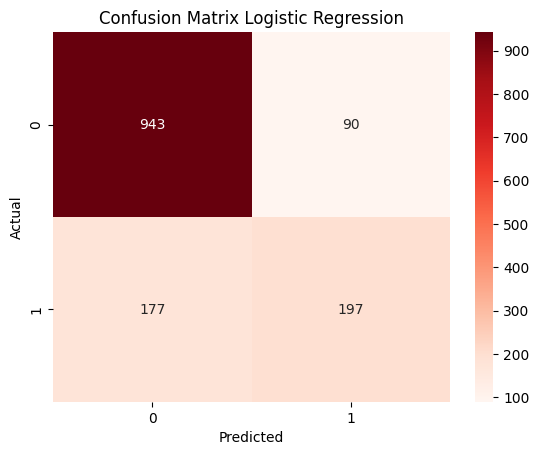

In [66]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Logistic Regression")
plt.show()

In [67]:
import joblib

In [68]:
joblib.dump(lr, "../models/logistic_model.pkl")

['../models/logistic_model.pkl']

#### b. Random Forest Classifier

In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
rf = RandomForestClassifier(n_estimators=100, random_state=7)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [71]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.68      0.51      0.58       374

    accuracy                           0.81      1407
   macro avg       0.76      0.71      0.73      1407
weighted avg       0.80      0.81      0.80      1407



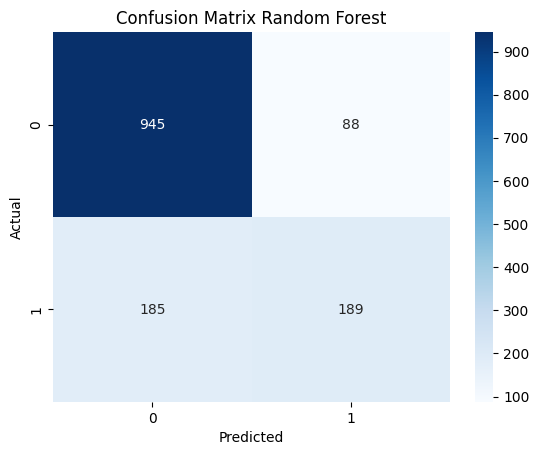

In [72]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Random Forest")
plt.show()

In [73]:
joblib.dump(rf, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

#### c. XGBoost Classifier

In [ ]:
%pip install xgboost

In [75]:
from xgboost import XGBClassifier

In [85]:
xgb = XGBClassifier(
    random_state=7,
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [86]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.91      0.87      1033
           1       0.68      0.54      0.60       374

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.74      1407
weighted avg       0.80      0.81      0.80      1407



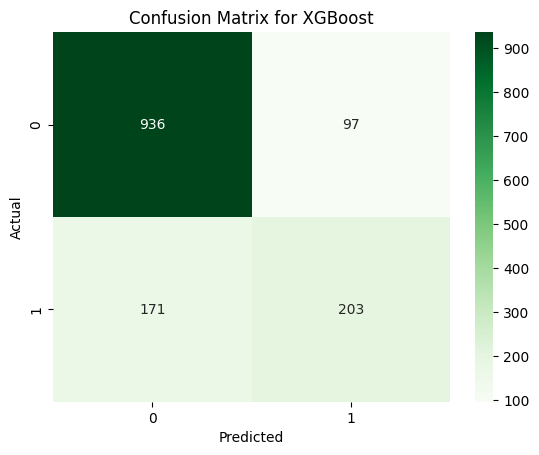

In [87]:
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for XGBoost")
plt.show()

In [88]:
joblib.dump(xgb, "../models/xgb_model.pkl")

['../models/xgb_model.pkl']

## Model Explainability

In [ ]:
%pip install shap

In [90]:
import shap

/home/matei/Churn-Analysis-Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [91]:
explainer = shap.Explainer(lr, X_train)
shap_values = explainer(X_test)

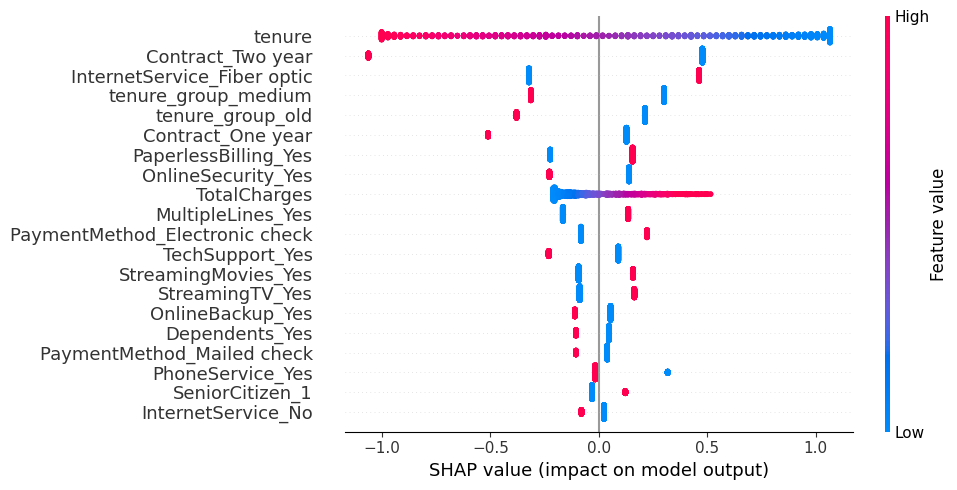

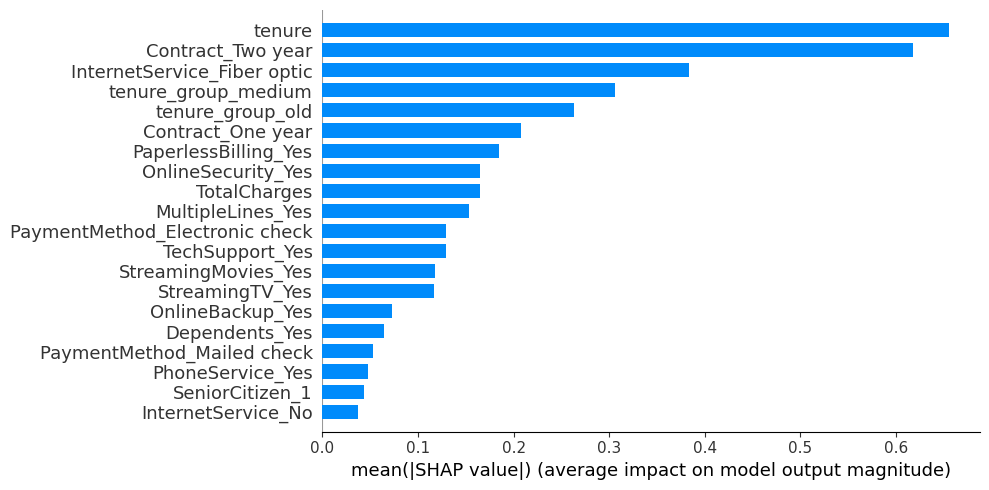

In [92]:
shap.summary_plot(shap_values, X_test, plot_size=(10,5))
shap.summary_plot(shap_values, X_test, plot_type="bar", plot_size=(10,5))

### OBS:

Top drivers of Churn:

1. tenure

-   Red (high tenure) => negative SHAP => less likely to churn

-   Blue (low tenure) => positive SHAP => more likely to churn

-   Insight: New customers are more likely to churn

2. Contract_Two year

-   Red (two year contract) => negative SHAP => less likely to churn

-   Insight: Long term contracts reduce churn

3. InternetService_Fiber optic

-   Red (customer has fiber) => increases churn by a bit

-   Insight: Customers with fiber churn a bit more, due to extra costs (maybe)


In [93]:
explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

 98%|===================| 1374/1407 [00:37<00:00]        

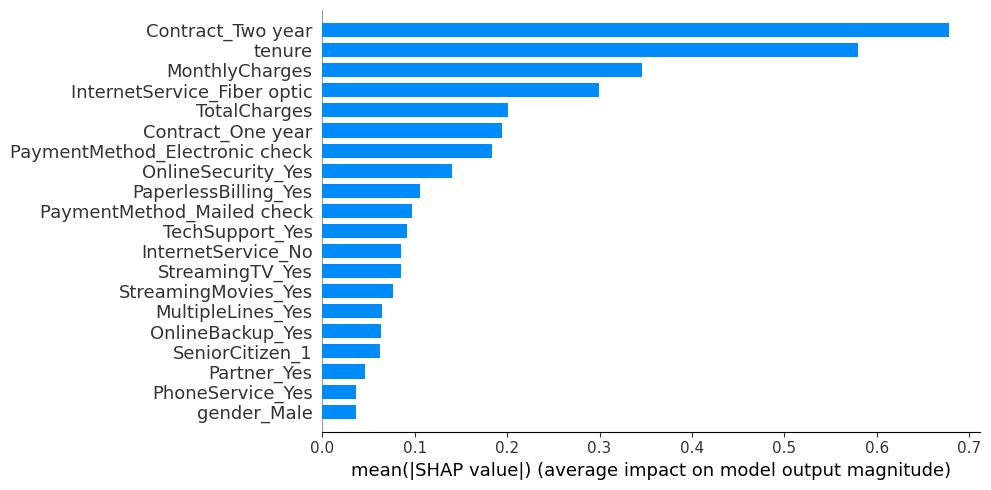

In [94]:
shap.summary_plot(shap_values, X_test, plot_type="bar", plot_size=(10,5))